# 学习菜谱RAG系统

In [ ]:
!pip install requirements.txt
!pip install python-dotenv

In [ ]:
from dotenv import load_dotenv
import 

load_dotenv()

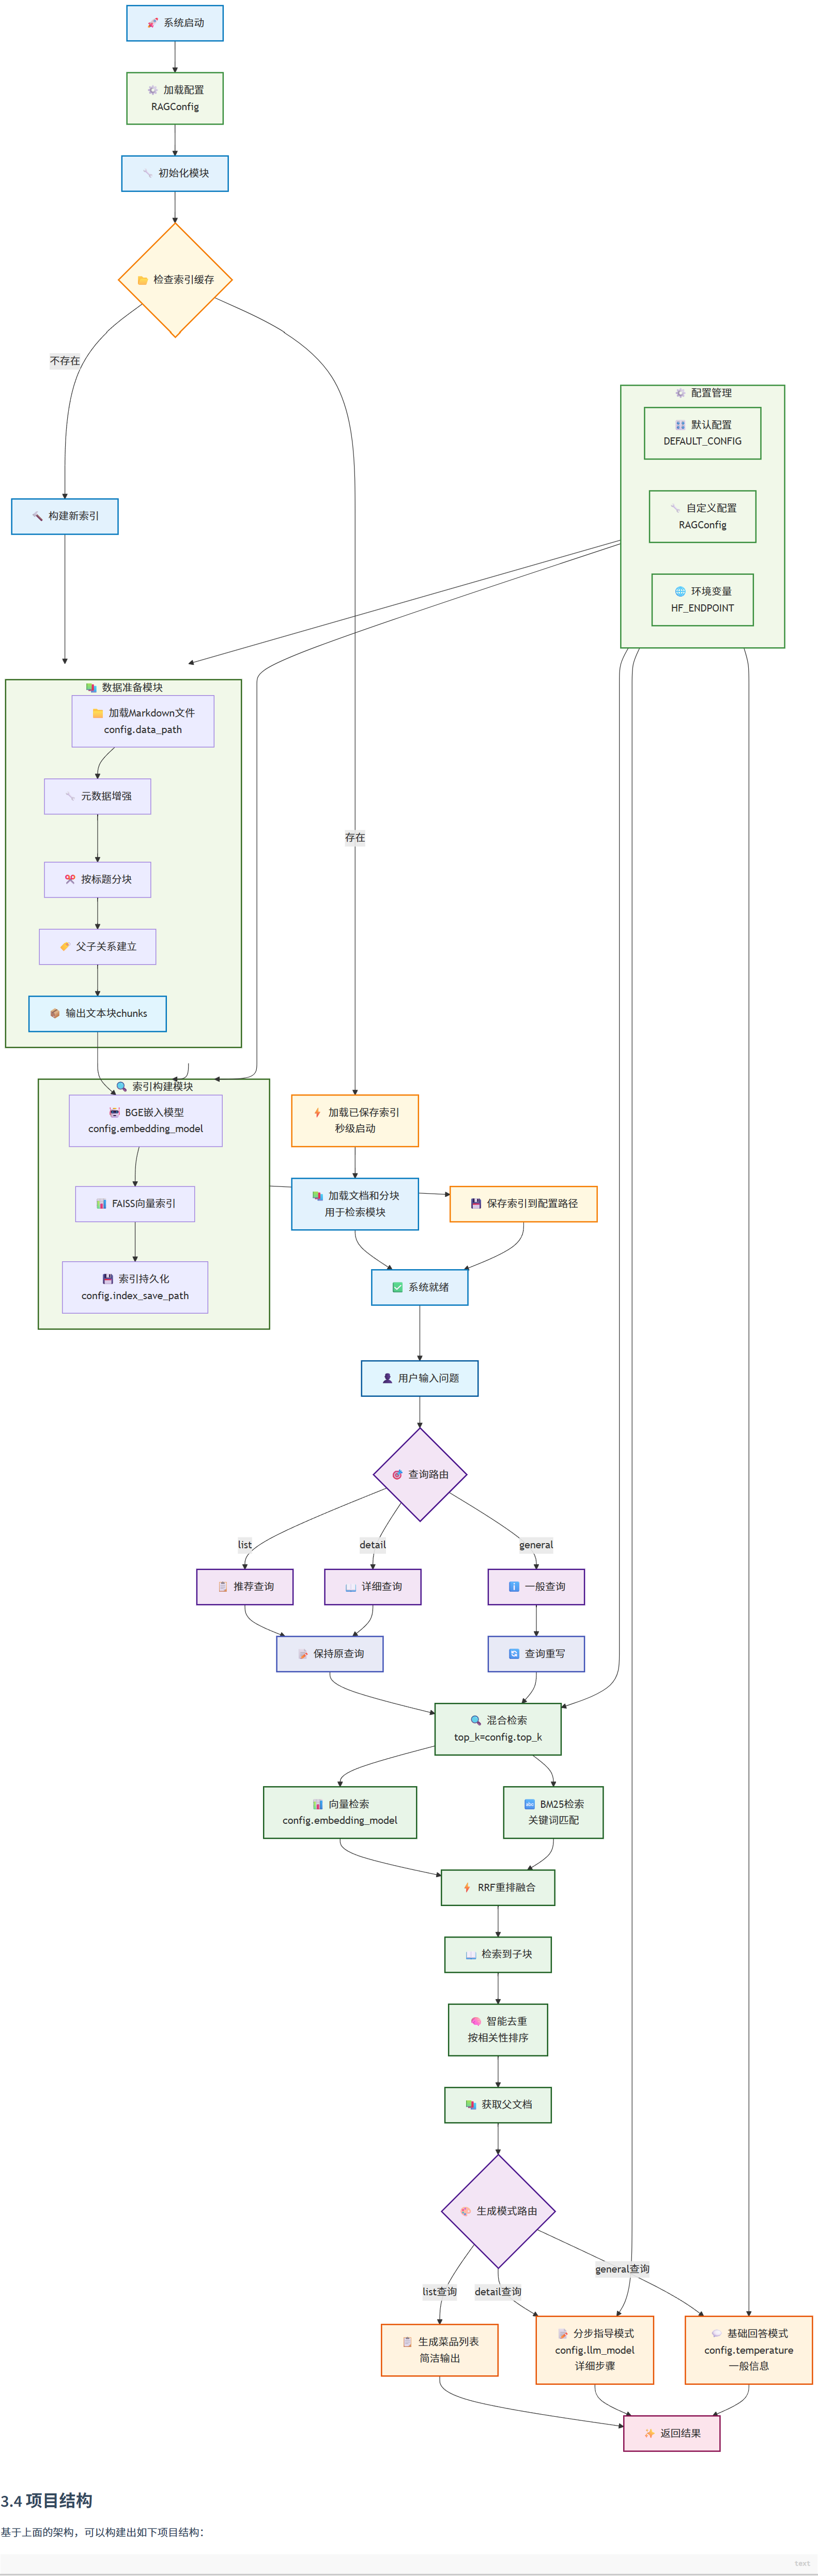

# 数据模块准备

原作者说，菜谱是markdown的格式，每个菜谱都有多个章节，这里把每个菜谱的每个章节切开，然后用小块进行检索，然后用大块信息进行生成

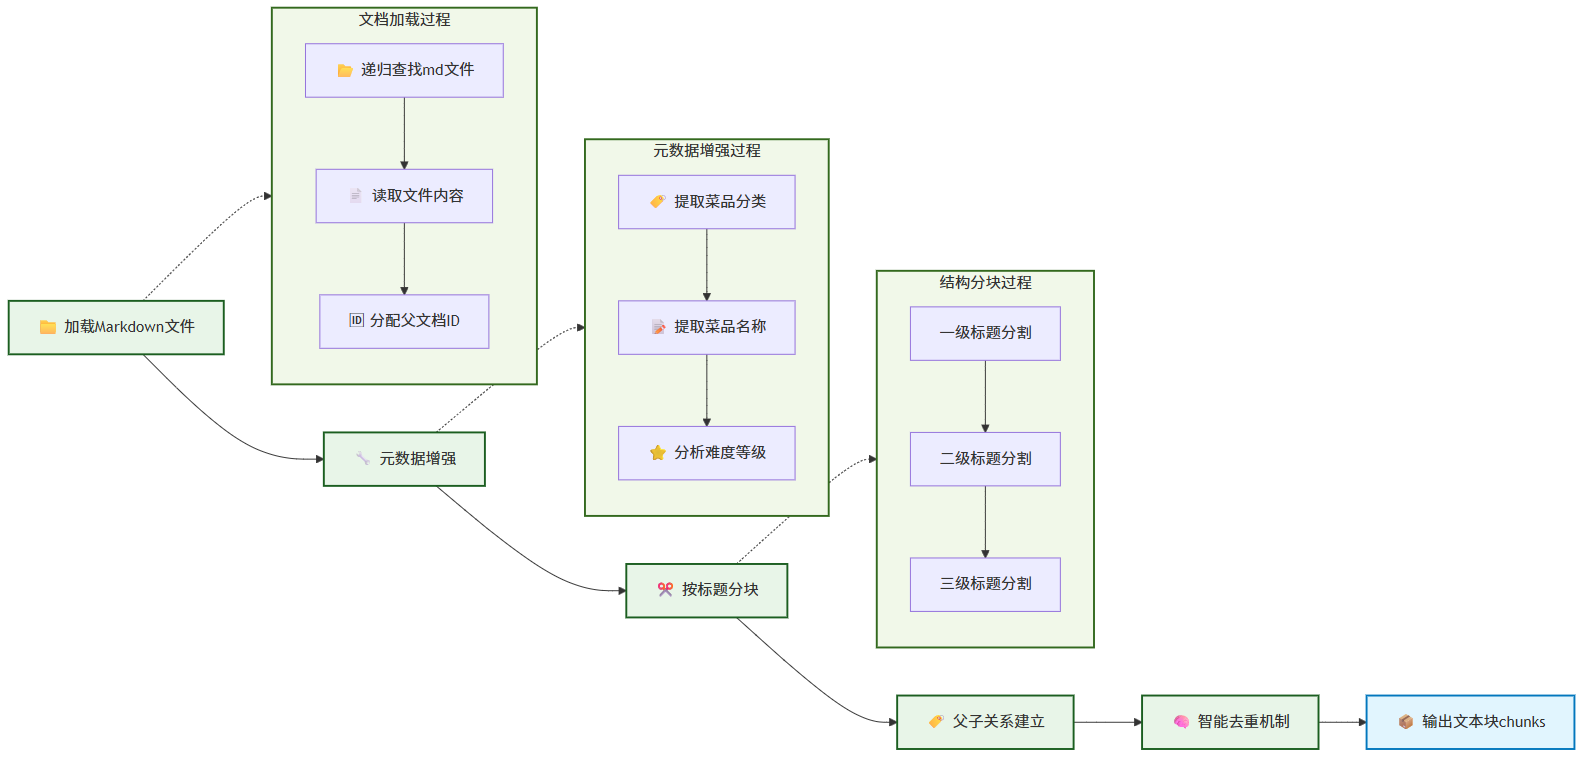

父文档（完整菜谱）

├── 子块1：菜品介绍 + 难度评级

├── 子块2：必备原料和工具

├── 子块3：计算（用量配比）

├── 子块4：操作（制作步骤）

└── 子块5：附加内容（变化做法）

**基本流程：**

检索阶段：使用小的子块进行精确匹配，提高检索准确性

生成阶段：传递完整的父文档给LLM，确保上下文完整性

智能去重：当检索到同一道菜的多个子块时，合并为一个完整菜谱

**元数据增强：**

菜品分类：从文件路径推断（荤菜、素菜、汤品等）

难度等级：从内容中的星级标记提取

菜品名称：从文件名提取

文档关系：建立父子文档的ID映射关系

In [ ]:
# 类结构设计
from typing import List, Dict
from langchain_core.documents import Document  

class DataPreparationModule:
    """数据准备模块，负责数据记载，清洗和预处理"""
    def __init__(self, data_path:str) :
        self.data_path = data_path
        self.documents : List[Document] = [] # 存储原始文档
        self.chunks : List[Document] = [] # 存储切分后的文档块
        self.parent_child_map : Dict[str, str] = {} # 存储父子关系映射

## 批量加载markdown文件

In [ ]:
from pathlib import Path
import uuid

def load_documents(self) -> List[Document]:
    """加载文档数据"""
    documents = []
    data_path_obj = Path(self.data_path) # 这里是一个路径对象
    
    for md_file in data_path_obj.rglob("*.md"): # rglob递归查找所有md文件
        with open(md_file, "r", encoding="utf-8") as f:
            content = f.read()
        
        parent_id = str(uuid.uuid4()) # 生成唯一的父ID
        
        # 创建Document对象
        doc = Document(
            page_content = content
            metadata = {
                "source" : str(md_file), # 文件路径作为来源
                "parent_id" : parent_id # 父ID
                "doc_type" : "parent" # 标记为父文档
            }
        )
        
        documents.append(doc)
        
    for doc in documents:
        self._enhance_metadata(doc) # 增强元数据，提取标题等信息
    
    self.documents = documents
    
    return documents